## First exploration analysis on mvTEC dataset


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random

data_path = Path("../screw")

print("Struktura:")
for folder in data_path.rglob("*"):
    if folder.is_dir():
        num_files = len(list(folder.glob("*.png")))
        if num_files > 0:
            print(f"{folder.relative_to(data_path)}: {num_files} images")

Struktura:
ground_truth\manipulated_front: 24 images
ground_truth\scratch_head: 24 images
ground_truth\scratch_neck: 25 images
ground_truth\thread_side: 23 images
ground_truth\thread_top: 23 images
screw\ground_truth\manipulated_front: 24 images
screw\ground_truth\scratch_head: 24 images
screw\ground_truth\scratch_neck: 25 images
screw\ground_truth\thread_side: 23 images
screw\ground_truth\thread_top: 23 images
screw\test\good: 41 images
screw\test\manipulated_front: 24 images
screw\test\scratch_head: 24 images
screw\test\scratch_neck: 25 images
screw\test\thread_side: 23 images
screw\test\thread_top: 23 images
screw\train\good: 320 images
test\good: 41 images
test\manipulated_front: 24 images
test\scratch_head: 24 images
test\scratch_neck: 25 images
test\thread_side: 23 images
test\thread_top: 23 images
train\good: 320 images


Training OK images: 320


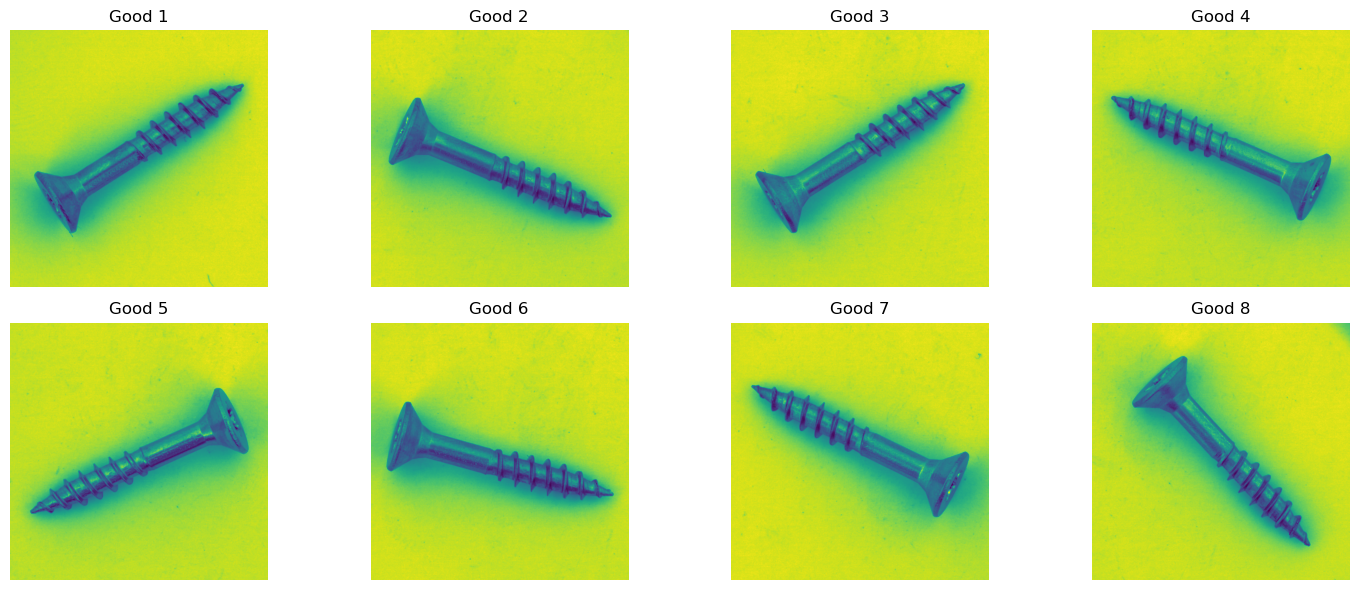

In [3]:
def show_images(image_paths, titles=None, cols=4):
    n = len(image_paths)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))
    axes = axes.flatten() if n > 1 else [axes]
    
    for idx, img_path in enumerate(image_paths):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')
        if titles:
            axes[idx].set_title(titles[idx])
    
    # Wyłącz puste subploty
    for idx in range(n, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Przykładowe OK śruby (train)
good_train = list((data_path / "train/good").glob("*.png"))
print(f"Training OK images: {len(good_train)}")

# Pokaż 8 losowych
random_good = random.sample(good_train, 8)
show_images(random_good, titles=[f"Good {i+1}" for i in range(8)])

Defect types: ['manipulated_front', 'scratch_head', 'scratch_neck', 'thread_side', 'thread_top']


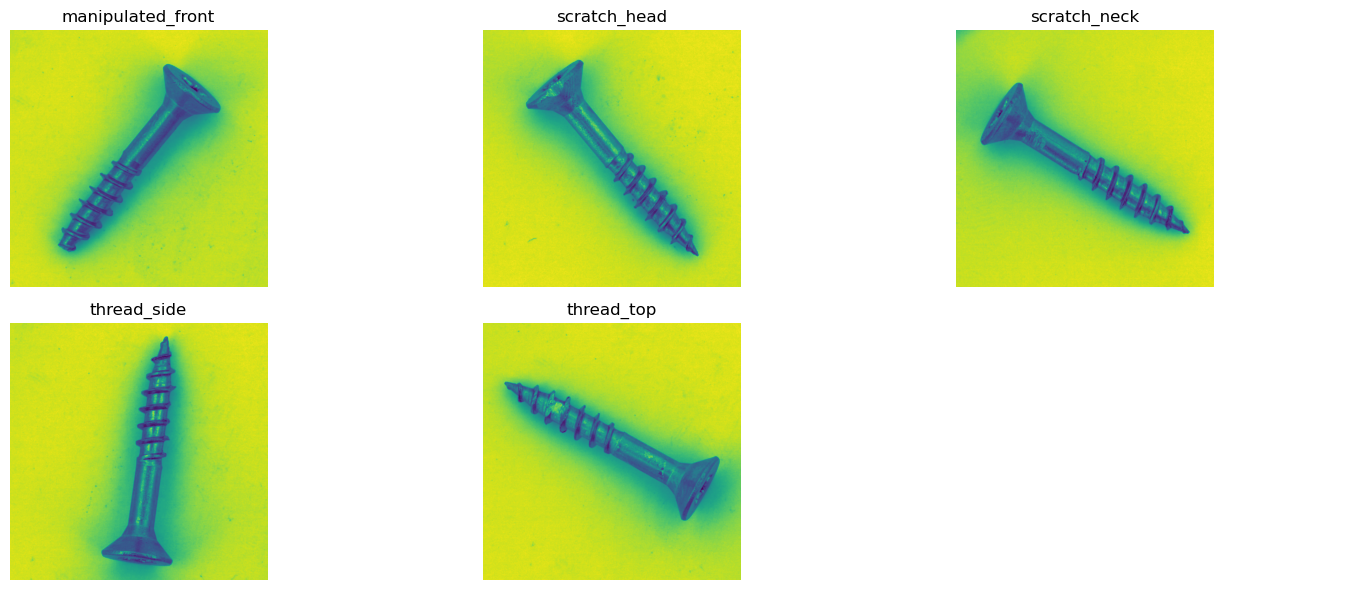

In [4]:
test_path = data_path / "test"
defect_types = [d.name for d in test_path.iterdir() if d.is_dir() and d.name != "good"]

print(f"Defect types: {defect_types}")

# Pokaż po jednym przykładzie każdego defektu
examples = []
titles = []

for defect in defect_types:
    defect_images = list((test_path / defect).glob("*.png"))
    if defect_images:
        examples.append(defect_images[0])
        titles.append(defect)

show_images(examples, titles=titles, cols=3)

In [5]:
img = Image.open(good_train[0])
print(f"Image size: {img.size}")  # (width, height)
print(f"Image mode: {img.mode}")  # RGB, L, etc.

# Sprawdź czy wszystkie mają ten sam rozmiar
sizes = set()
for img_path in good_train[:50]:  # sprawdź pierwsze 50
    img = Image.open(img_path)
    sizes.add(img.size)

print(f"Unique sizes in sample: {sizes}")

Image size: (1024, 1024)
Image mode: L
Unique sizes in sample: {(1024, 1024)}


In [6]:
import pandas as pd

# Policz wszystkie obrazki
data = []

# Train (tylko good)
train_good = len(list((data_path / "train/good").glob("*.png")))
data.append({"Split": "Train", "Category": "good", "Count": train_good})

# Test (good + defects)
test_good = len(list((test_path / "good").glob("*.png")))
data.append({"Split": "Test", "Category": "good", "Count": test_good})

for defect in defect_types:
    count = len(list((test_path / defect).glob("*.png")))
    data.append({"Split": "Test", "Category": defect, "Count": count})

df = pd.DataFrame(data)
print(df)
print(f"\nTotal images: {df['Count'].sum()}")

   Split           Category  Count
0  Train               good    320
1   Test               good     41
2   Test  manipulated_front     24
3   Test       scratch_head     24
4   Test       scratch_neck     25
5   Test        thread_side     23
6   Test         thread_top     23

Total images: 480
